# Mask R-CNN (fine-tuned) — demo

Run the fine-tuned Mask R-CNN leaf segmenter on one image.

## Setup — do this first

In a terminal, **from this folder**, create the virtualenv and install the
dependencies **before running any cell below**:

```bash
cd models/04_mask_rcnn
python3 -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
```

Then select `.venv` as this notebook's kernel and run the cells top to bottom.

## 1. Load the model + fine-tuned weights

In [1]:
import os, sys
import numpy as np
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS = "finetuned.pth"        # produced by train_mask_rcnn.py
NUM_CLASSES = 2                  # background + leaf

# rebuild the same 2-class architecture used for training, then load the weights
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None, weights_backbone=None)
in_feat = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)
in_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, NUM_CLASSES)
model.load_state_dict(torch.load(WEIGHTS, map_location="cpu"))
model = model.eval().to(DEVICE)
print("loaded Mask R-CNN on", DEVICE)

loaded Mask R-CNN on cuda


## 2. Predict on a sample image

In [2]:
sys.path.insert(0, os.path.abspath("../.."))     # repo root, for the shared helper
from shared.helper import load_image, overlay_masks

SAMPLE = "../../data/cvppp/testing/images/A1/plant001_rgb.png"
image = load_image(SAMPLE)                        # (H, W, 3) uint8 RGB

tensor = torch.from_numpy(image).permute(2, 0, 1).float().div(255).to(DEVICE)
with torch.inference_mode():
    pred = model([tensor])[0]

keep = pred["scores"].cpu().numpy() >= 0.5        # keep confident detections
masks = list(pred["masks"].cpu().numpy()[keep, 0] > 0.5)   # list of (H, W) bool masks
print(f"found {len(masks)} leaves")

found 12 leaves


## 3. Show the output

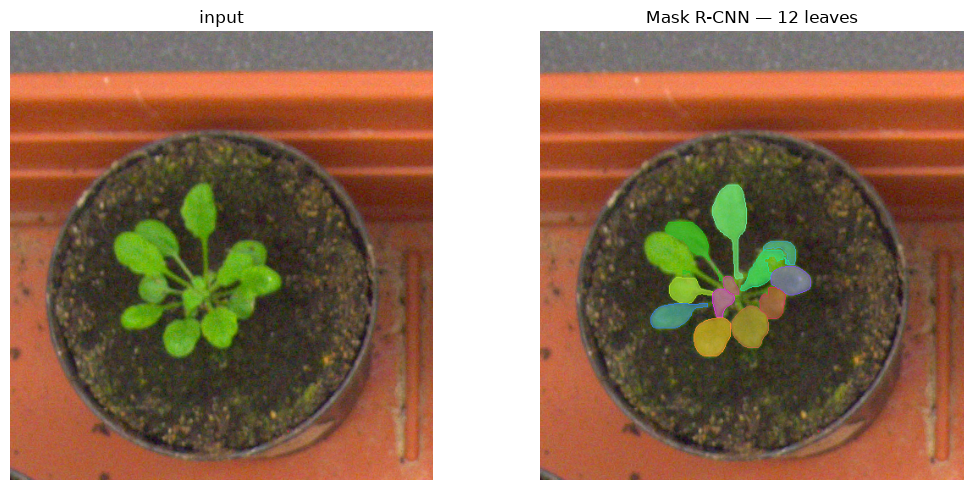

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(image);                        ax[0].set_title("input")
ax[1].imshow(overlay_masks(image, masks));  ax[1].set_title(f"Mask R-CNN — {len(masks)} leaves")
for a in ax:
    a.axis("off")
plt.tight_layout();